## Importing Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

### Importing Dataset

In [4]:
import os
from google.cloud import bigquery
import pandas as pd

# 1. Point Python to your GCP Service Account Key
# Change this path to match exactly where it is on your Windows machine
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\User\Documents\Projects\aus-auto-arbitrage-pipeline\secrets\root-anvil-474411-k5-fdd00fadc7e2.json"

# 2. Initialize the BigQuery Client
client = bigquery.Client()

# 3. Write the SQL to grab your Silver data
# Adjust the table name if your silver table is named differently
query = """
    SELECT * 
    FROM `root-anvil-474411-k5.aus_auto_silver.stg_vehicle_listings`
"""

# 4. Download it straight into a Pandas DataFrame!
print("Downloading data from BigQuery...")
df = client.query(query).to_dataframe()

print(f"Success! Downloaded {len(df)} rows.")
display(df.head())

c:\Users\User\Documents\Projects\aus-auto-arbitrage-pipeline\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Success! Downloaded 16056 rows.


,listing_id,brand,vehicle_year,model,car_suv,title,used_or_new,transmission,drive_type,fuel_type,...,colour_ext_int_raw,price,kilometres,engine_cylinders,fuel_consumption_l_100km,doors,seats,city,state,exterior_colour
0,0878c31628ba66ec1276a3bba4985e43,Toyota,1998,Other,Australian Motor Traders,1998 Toyota Other,USED,Manual,Rear,Premium,...,Gold / -,59990,158001,<NA>,NaN,5,<NA>,Haberfield,NSW,Gold
1,12611c6ce064f09b161f8351d548de3b,Kia,2008,RIO,Easy Wholesale,2008 Kia RIO JB LX Hatchback 5dr Man 5sp 1.4i,USED,Manual,Front,Unleaded,...,Silver / -,7200,168737,<NA>,NaN,<NA>,<NA>,Wangara,WA,Silver
2,24a18f61c2f4f8426717b0b10d7340a1,BMW,2014,X5,SUV,2014 BMW X5 Xdrive 30D,USED,Automatic,AWD,Diesel,...,Black / Black,47888,69425,6,6.2,4,5,South Melbourne,VIC,Black
3,25387478c307102d05af61c7e3378cc4,Ford,2020,Puma,SUV,2020 Ford Puma ST-Line,USED,Automatic,Front,Premium,...,Grey / Black,28990,29866,3,5.3,5,5,Arncliffe,NSW,Grey
4,265f4aa00cf653381c9d96c1a5586995,Hyundai,2018,Iload,Commercial,2018 Hyundai Iload 3S Liftback,USED,Automatic,Rear,Diesel,...,White / -,32980,119544,4,8.8,4,3,Fairfield East,NSW,White


#### Copy for later

In [5]:
df_silver = df.copy()

In [6]:
df.tail()

,listing_id,brand,vehicle_year,model,car_suv,title,used_or_new,transmission,drive_type,fuel_type,...,colour_ext_int_raw,price,kilometres,engine_cylinders,fuel_consumption_l_100km,doors,seats,city,state,exterior_colour
16051,26ef7261b296cce453ff9b3d11a0c68e,Toyota,2012,Yaris,Hatchback,2012 Toyota Yaris YRX,USED,Automatic,Front,Unleaded,...,Blue / -,15999,108000,4,6.3,5,5,Werribee,VIC,Blue
16052,1c7077857a4103c774d1a72759e68c9b,Toyota,2020,Yaris,SUV,2020 Toyota Yaris Cross GX Hybrid,USED,Automatic,Front,Hybrid,...,White / -,32990,55929,3,3.8,4,5,Alexandria,NSW,White
16053,4a6982c130921924212297623a4c06c1,Toyota,2010,Yaris,Hatchback,2010 Toyota Yaris YR,USED,Automatic,Front,Unleaded,...,Blue / -,8990,193500,4,6.5,5,5,Mount Lawley,WA,Blue
16054,a15628c25ec7329480337c621e3963af,Toyota,2012,Yaris,Hatchback,2012 Toyota Yaris YR,USED,Automatic,Front,Unleaded,...,- / -,11990,152805,4,6.3,5,5,Cabramatta,NSW,-
16055,bcf779866a38db512a1fab7595002992,Toyota,2010,Yaris,Hatchback,2010 Toyota Yaris YR,USED,Manual,Front,Unleaded,...,Silver / -,5750,251945,4,6.0,5,5,Minto,NSW,Silver


## Exploring the Dataset

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16056 entries, 0 to 16055
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   listing_id                16056 non-null  str    
 1   brand                     16056 non-null  str    
 2   vehicle_year              16056 non-null  Int64  
 3   model                     16056 non-null  str    
 4   car_suv                   16053 non-null  str    
 5   title                     16056 non-null  str    
 6   used_or_new               16056 non-null  str    
 7   transmission              15841 non-null  str    
 8   drive_type                16056 non-null  str    
 9   fuel_type                 15514 non-null  str    
 10  body_type                 15788 non-null  str    
 11  engine_raw                14431 non-null  str    
 12  location_raw              16056 non-null  str    
 13  colour_ext_int_raw        16056 non-null  str    
 14  price            

### Dedeupliication

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

### Dropping Redundant Features

In [10]:
df=df.drop(['colour_ext_int_raw','car_suv','model','title'],axis=1)

### Replace Undefined Values 

In [11]:
df.replace(['-','POA','- / -'],np.nan,inplace=True)

,listing_id,brand,vehicle_year,used_or_new,transmission,drive_type,fuel_type,body_type,engine_raw,location_raw,price,kilometres,engine_cylinders,fuel_consumption_l_100km,doors,seats,city,state,exterior_colour
0,0878c31628ba66ec1276a3bba4985e43,Toyota,1998,USED,Manual,Rear,Premium,Sedan,NaN,"Haberfield, NSW",59990,158001,<NA>,NaN,5,<NA>,Haberfield,NSW,Gold
1,12611c6ce064f09b161f8351d548de3b,Kia,2008,USED,Manual,Front,Unleaded,Hatchback,NaN,"Wangara, WA",7200,168737,<NA>,NaN,<NA>,<NA>,Wangara,WA,Silver
2,24a18f61c2f4f8426717b0b10d7340a1,BMW,2014,USED,Automatic,AWD,Diesel,SUV,"6 cyl, 3 L","South Melbourne, VIC",47888,69425,6,6.2,4,5,South Melbourne,VIC,Black
3,25387478c307102d05af61c7e3378cc4,Ford,2020,USED,Automatic,Front,Premium,SUV,"3 cyl, 1 L","Arncliffe, NSW",28990,29866,3,5.3,5,5,Arncliffe,NSW,Grey
4,265f4aa00cf653381c9d96c1a5586995,Hyundai,2018,USED,Automatic,Rear,Diesel,Commercial,"4 cyl, 2.5 L","Fairfield East, NSW",32980,119544,4,8.8,4,3,Fairfield East,NSW,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16051,26ef7261b296cce453ff9b3d11a0c68e,Toyota,2012,USED,Automatic,Front,Unleaded,Hatchback,"4 cyl, 1.5 L","Werribee, VIC",15999,108000,4,6.3,5,5,Werribee,VIC,Blue
16052,1c7077857a4103c774d1a72759e68c9b,Toyota,2020,USED,Automatic,Front,Hybrid,SUV,"3 cyl, 1.5 L","Alexandria, NSW",32990,55929,3,3.8,4,5,Alexandria,NSW,White
16053,4a6982c130921924212297623a4c06c1,Toyota,2010,USED,Automatic,Front,Unleaded,Hatchback,"4 cyl, 1.3 L","Mount Lawley, WA",8990,193500,4,6.5,5,5,Mount Lawley,WA,Blue
16054,a15628c25ec7329480337c621e3963af,Toyota,2012,USED,Automatic,Front,Unleaded,Hatchback,"4 cyl, 1.3 L","Cabramatta, NSW",11990,152805,4,6.3,5,5,Cabramatta,NSW,NaN


In [12]:
df.isnull().sum()

listing_id                     0
brand                          0
vehicle_year                   0
used_or_new                    0
transmission                 215
drive_type                     0
fuel_type                    542
body_type                    268
engine_raw                  1625
location_raw                   0
price                          0
kilometres                     0
engine_cylinders            1625
fuel_consumption_l_100km    1648
doors                       1556
seats                       1648
city                           0
state                          0
exterior_colour              391
dtype: int64

## Outlier Analysis

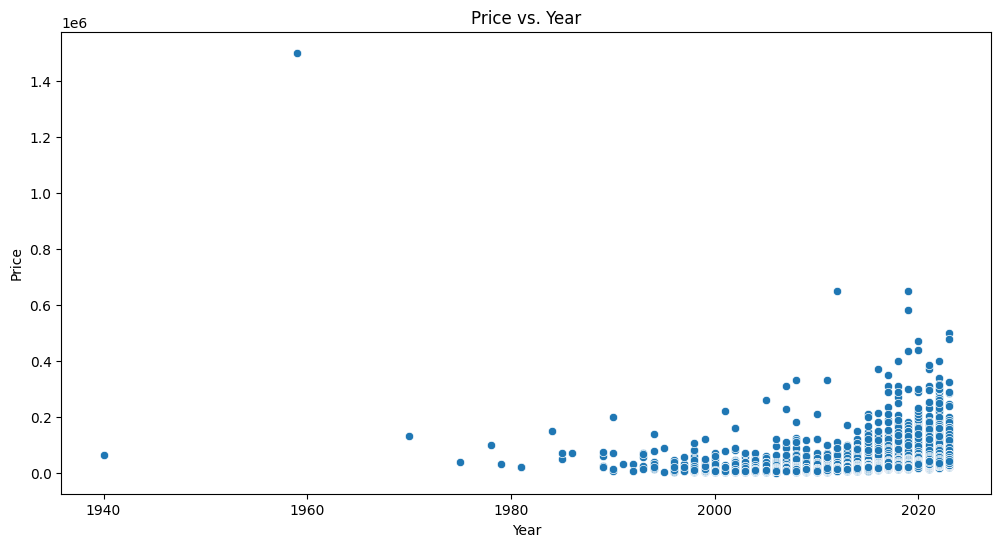

In [13]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['vehicle_year'], y=df['price'])
plt.title('Price vs. Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

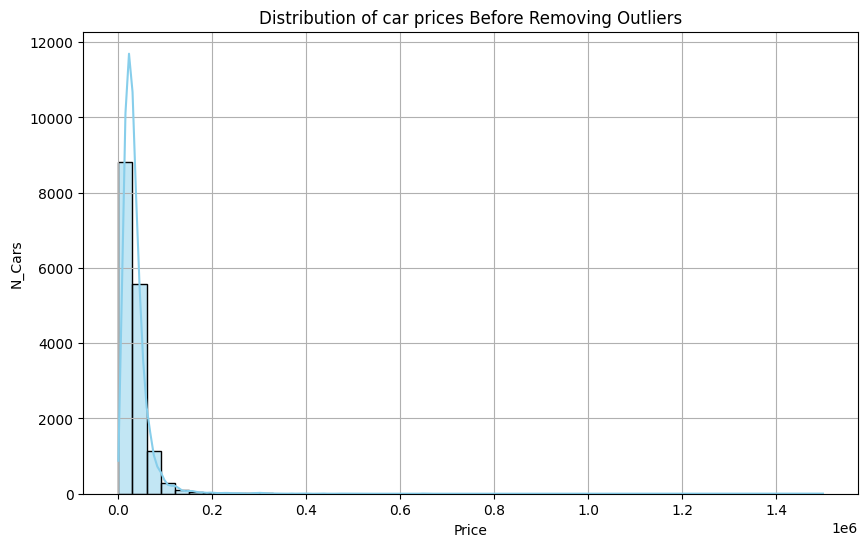

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of car prices Before Removing Outliers")
plt.xlabel("Price")
plt.ylabel("N_Cars")
plt.grid(True)
plt.show()

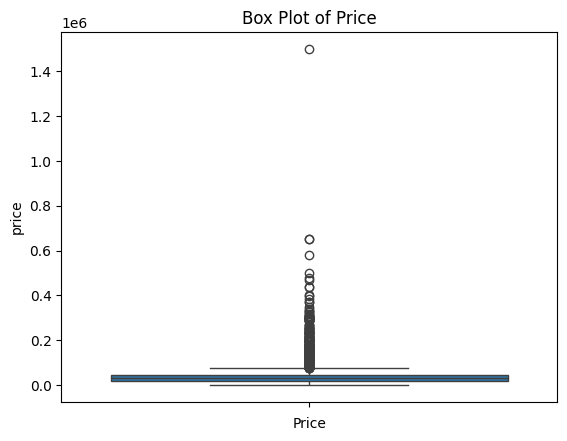

In [15]:
sns.boxplot(df['price'])
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

#### Ignoring Data Outside IQR

outlier percentage 5.39%


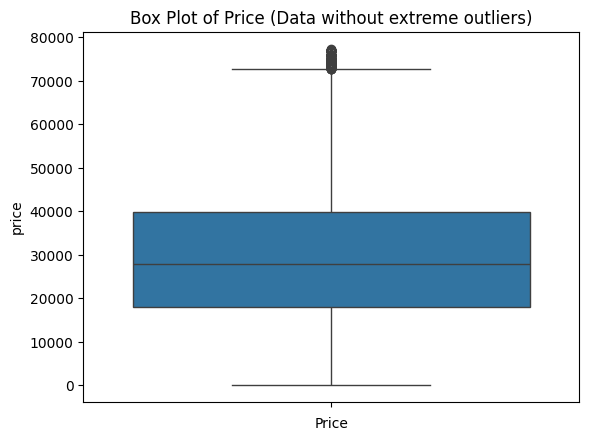

In [16]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outlier_percentage = (len(outliers) / len(df)) * 100
print(f"outlier percentage {outlier_percentage:.2f}%")
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
sns.boxplot(df['price'])
plt.title('Box Plot of Price (Data without extreme outliers)')
plt.xlabel('Price')
plt.show()

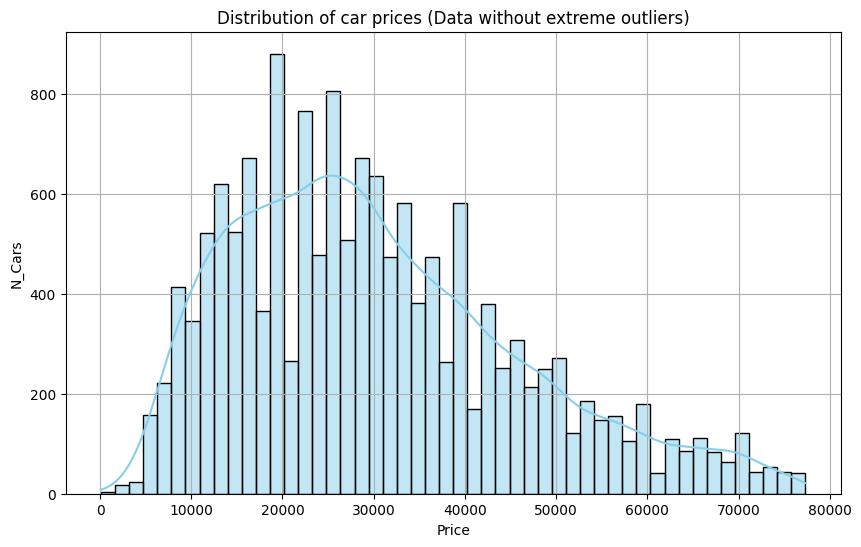

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of car prices (Data without extreme outliers)")
plt.xlabel("Price")
plt.ylabel("N_Cars")
plt.grid(True)
plt.show()

### Handling Outliers WRT FuelConsumption

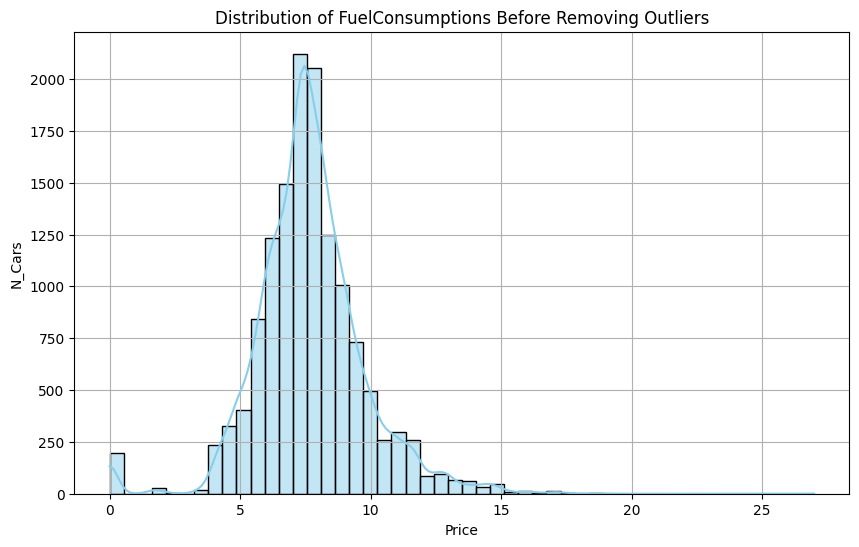

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fuel_consumption_l_100km'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of FuelConsumptions Before Removing Outliers")
plt.xlabel("Price")
plt.ylabel("N_Cars")
plt.grid(True)
plt.show()

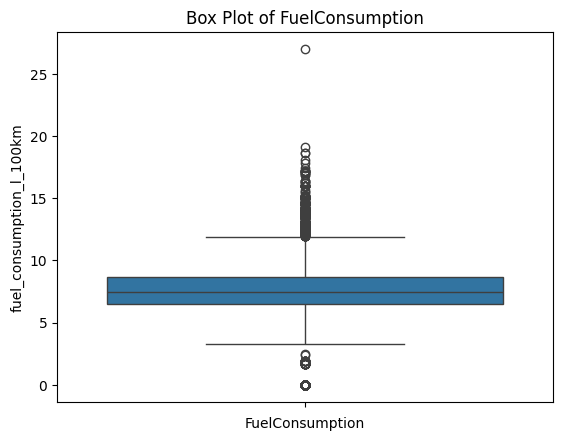

In [19]:
sns.boxplot(df['fuel_consumption_l_100km'])
plt.title('Box Plot of FuelConsumption')
plt.xlabel('FuelConsumption')
plt.show()

outlier percentage 0.42%


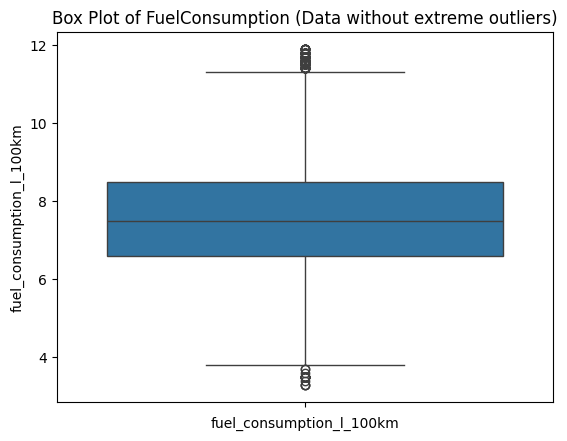

In [20]:
Q1 = df['fuel_consumption_l_100km'].quantile(0.25)
Q3 = df['fuel_consumption_l_100km'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['fuel_consumption_l_100km'] < lower_bound) | (df['fuel_consumption_l_100km'] > upper_bound)]
outlier_percentage = (len(outliers) / len(df)) * 10
print(f"outlier percentage {outlier_percentage:.2f}%")
df = df[(df['fuel_consumption_l_100km'] >= lower_bound) & (df['fuel_consumption_l_100km'] <= upper_bound)]
sns.boxplot(df['fuel_consumption_l_100km'])
plt.title('Box Plot of FuelConsumption (Data without extreme outliers)')
plt.xlabel('fuel_consumption_l_100km')
plt.show()

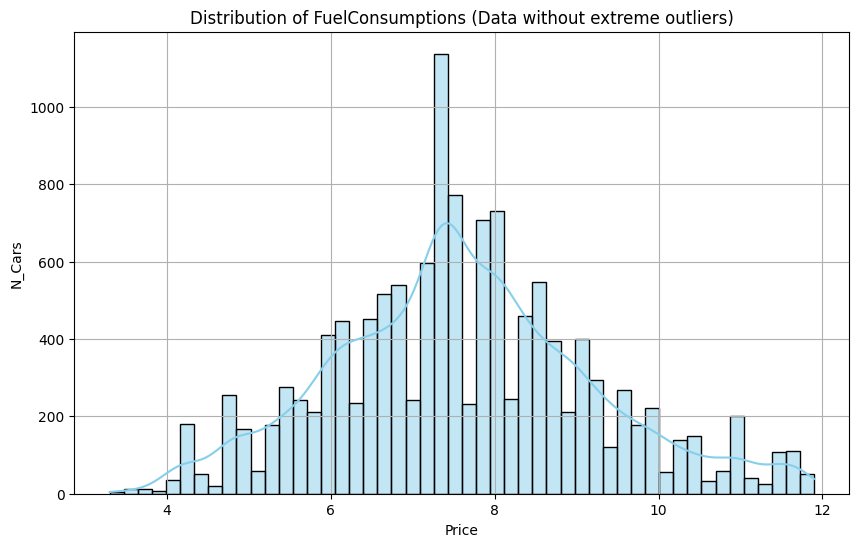

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fuel_consumption_l_100km'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of FuelConsumptions (Data without extreme outliers)")
plt.xlabel("Price")
plt.ylabel("N_Cars")
plt.grid(True)
plt.show()

### Categorical Encoding

In [22]:
df=pd.get_dummies(df,columns=['used_or_new', 'transmission'], drop_first=True,dtype=int)

In [23]:
df.head()

,listing_id,brand,vehicle_year,drive_type,fuel_type,body_type,engine_raw,location_raw,price,kilometres,engine_cylinders,fuel_consumption_l_100km,doors,seats,city,state,exterior_colour,used_or_new_NEW,used_or_new_USED,transmission_Manual
2,24a18f61c2f4f8426717b0b10d7340a1,BMW,2014,AWD,Diesel,SUV,"6 cyl, 3 L","South Melbourne, VIC",47888,69425,6,6.2,4,5,South Melbourne,VIC,Black,0,1,0
3,25387478c307102d05af61c7e3378cc4,Ford,2020,Front,Premium,SUV,"3 cyl, 1 L","Arncliffe, NSW",28990,29866,3,5.3,5,5,Arncliffe,NSW,Grey,0,1,0
4,265f4aa00cf653381c9d96c1a5586995,Hyundai,2018,Rear,Diesel,Commercial,"4 cyl, 2.5 L","Fairfield East, NSW",32980,119544,4,8.8,4,3,Fairfield East,NSW,White,0,1,0
5,2bc828175366c04ceaef21473afe840c,Holden,2018,4WD,Diesel,SUV,"4 cyl, 2.8 L","Gawler South, SA",31850,95112,4,8.6,4,7,Gawler South,SA,White,0,1,0
7,30178c476827fd13ded8ff5699706069,Hyundai,2012,Front,Unleaded,SUV,"4 cyl, 2 L","Minchinbury, NSW",9800,181595,4,8.5,4,5,Minchinbury,NSW,Silver,0,1,1


In [24]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('price')
categorical_columns = df.select_dtypes(include=['object']).columns

C:\Users\User\AppData\Local\Temp\ipykernel_48688\992994097.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [25]:
for col in categorical_columns:
    print(f"\n column: {col}")
    print(df[col].value_counts())
    print(f"number of class = {df[col].nunique()}\n")


 column: listing_id
listing_id
24a18f61c2f4f8426717b0b10d7340a1    1
25387478c307102d05af61c7e3378cc4    1
265f4aa00cf653381c9d96c1a5586995    1
2bc828175366c04ceaef21473afe840c    1
30178c476827fd13ded8ff5699706069    1
                                   ..
26ef7261b296cce453ff9b3d11a0c68e    1
1c7077857a4103c774d1a72759e68c9b    1
4a6982c130921924212297623a4c06c1    1
a15628c25ec7329480337c621e3963af    1
bcf779866a38db512a1fab7595002992    1
Name: count, Length: 13032, dtype: int64
number of class = 13032


 column: brand
brand
Toyota           2013
Hyundai          1129
Mazda            1020
Mitsubishi        922
Holden            894
Ford              850
Nissan            771
Kia               754
Volkswagen        732
Subaru            516
Mercedes-Benz     402
Audi              357
BMW               330
Honda             318
Suzuki            243
Jeep              227
MG                206
Isuzu             174
Renault           150
GWM               150
Land              129


### Ignoring all the rare categories

In [26]:
def drop_rare_categories(df, column, threshold=10):
    value_counts = df[column].value_counts()
    rare_categories = value_counts[value_counts < threshold].index
    df_filtered = df[~df[column].isin(rare_categories)]
    return df_filtered

for col in ['brand', 'fuel_type', 'state', 'body_type']:
    df = drop_rare_categories(df, column=col)

In [27]:
for col in numeric_columns:
    print(f"\n column: {col}")
    print(df[col].value_counts())
    print(f"number of class = {df[col].nunique()}\n")


 column: vehicle_year
vehicle_year
2018    1412
2019    1306
2017    1144
2016     991
2020     976
2015     944
2021     922
2022     893
2014     744
2013     731
2012     581
2023     486
2011     418
2010     346
2009     270
2008     222
2007     185
2006     125
2005      99
2004      54
2003      27
2002      23
2000      20
2001      11
1999      11
1998       5
1996       3
1997       2
1989       1
1990       1
1995       1
Name: count, dtype: Int64
number of class = 31


 column: kilometres
kilometres
10        92
15        56
7         52
20        51
22        30
          ..
35929      1
55929      1
193500     1
152805     1
251945     1
Name: count, Length: 11771, dtype: Int64
number of class = 11771


 column: engine_cylinders
engine_cylinders
4    10696
6     1474
5      390
3      291
8      100
2        3
Name: count, dtype: Int64
number of class = 6


 column: fuel_consumption_l_100km
fuel_consumption_l_100km
7.4    695
7.9    473
7.3    439
8.1    416
7.5    390


### Calculating car age

In [28]:
df['CarAge'] = 2025 - df['vehicle_year']
df.drop('vehicle_year', axis=1, inplace=True)

### Segmentation (Binning)

In [29]:
def door_category(d):
    if d <= 3:
        return 'Small'
    elif d <= 5:
        return 'Standard'
    else:
        return 'Large'

df['DoorCategory'] = df['doors'].apply(door_category)
df.drop('doors', axis=1, inplace=True)


def seat_category(s):
    if s <= 2:
        return 'Small'
    elif s <= 5:
        return 'Standard'
    elif s <= 7:
        return 'Family'
    else:
        return 'Large'

df['SeatCategory'] = df['seats'].apply(seat_category)
df.drop('seats', axis=1, inplace=True)

In [30]:
df=df.drop('listing_id',axis=1)

In [31]:
df=df.drop('engine_raw',axis=1)

In [32]:
df=df.drop('location_raw',axis=1)

In [33]:
df=df.drop('city',axis=1)

In [34]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('price')
categorical_columns = df.select_dtypes(include=['object']).columns

C:\Users\User\AppData\Local\Temp\ipykernel_48688\992994097.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


### Splitting into training and testing sets

In [35]:
X=df.drop(['price'],axis=1)
y=df['price']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Numerical Imputation

In [37]:
imputer= SimpleImputer(strategy='mean')
X_train[numeric_columns] = imputer.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = imputer.transform(X_test[numeric_columns])

### Imputation && Encoding of categorical Columns

In [38]:
imputer2=SimpleImputer(strategy='most_frequent')
X_train[categorical_columns] = imputer2.fit_transform(X_train[categorical_columns])
X_test[categorical_columns] = imputer2.transform(X_test[categorical_columns])

encoder=LabelEncoder()
for i in categorical_columns:
  X_train[i]=encoder.fit_transform(X_train[i])
  X_test[i]=encoder.transform(X_test[i])

### Training the Model

In [39]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor())
])

### Parameter grid

In [40]:
xgb_params = {
    'xgb__n_estimators': [150, 200,500],
    'xgb__max_depth': [3, 7, 9],
    'xgb__learning_rate': [0.1, 0.05, 0.01],
}

### GridSearchCV with K-Fold

In [41]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [42]:
xgb_grid = GridSearchCV(pipe, xgb_params, cv=kf, scoring='r2')

### Fitting the Model

In [43]:
xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgb__learning_rate': [0.1, 0.05, ...], 'xgb__max_depth': [3, 7, ...], 'xgb__n_estimators': [150, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

### Check best parameters and score

In [44]:
print("XGBoost Best Params:", xgb_grid.best_params_)
print("XGBoost CV R²: %.4f" % xgb_grid.best_score_)

XGBoost Best Params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 500}
XGBoost CV R²: 0.9150


In [45]:
print(f"The mean test scores:\n{xgb_grid.cv_results_['mean_test_score']}")
print(f"The standard dev test scores:\n{xgb_grid.cv_results_['std_test_score']}")

The mean test scores:
[0.85265101 0.86356342 0.89320898 0.91024246 0.9125679  0.91504004
 0.90632671 0.90689765 0.90622284 0.81567357 0.83375707 0.87171426
 0.89947116 0.90474076 0.91379392 0.90408542 0.90643437 0.90879835
 0.63326079 0.68427062 0.78180189 0.77361127 0.82050061 0.88804723
 0.80303762 0.84494139 0.89748144]
The standard dev test scores:
[0.00558424 0.00538038 0.00641881 0.00700154 0.00701804 0.00700725
 0.00660291 0.00675295 0.00657808 0.00474987 0.00493091 0.00592874
 0.00778115 0.00796459 0.00790151 0.006279   0.00632026 0.00604582
 0.00740461 0.00725237 0.00540497 0.00582761 0.00674637 0.00749516
 0.00609205 0.00634523 0.00603699]


### Choosing the best model

In [46]:
best_model = xgb_grid.best_estimator_

### Evaluatng on the separated test set

In [47]:
y_pred = best_model.predict(X_test)
xgb_test_r2 = r2_score(y_test, y_pred)
print("XGBoost Test R²:", xgb_test_r2)

XGBoost Test R²: 0.9214795231819153


In [48]:
mse = mean_squared_error(y_test,y_pred)
print("MSE:", mse)

MSE: 18881356.0


In [49]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 3011.823974609375


In [50]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape, "%")

MAPE: 11.509442493751672 %


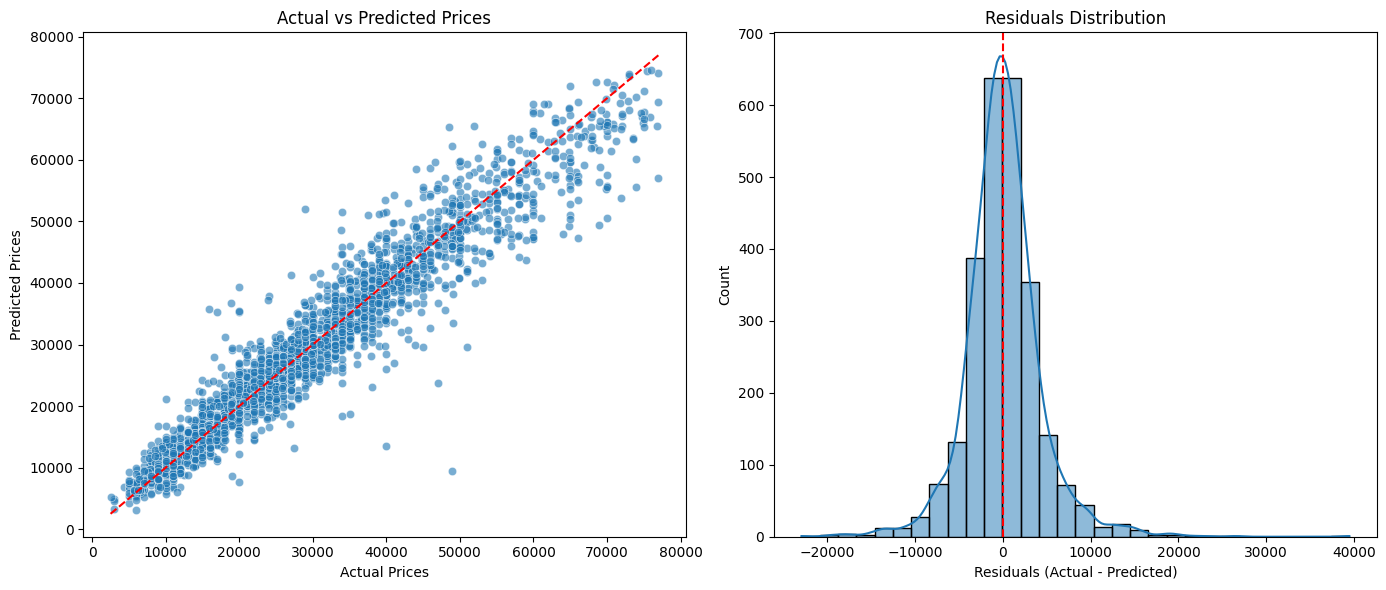

In [51]:
residuals = y_test - y_pred
plt.figure(figsize=(14, 6))
#1
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
#2
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("Residuals Distribution")
plt.tight_layout()
plt.show()

### Production Pipeline

In [ ]:
X_final = df.drop(['price'], axis=1, errors='ignore')
df['predicted_price'] = pipeline.predict(X_final)

# Reachng back into df_silver using the preserved index to grab the correct IDs
df['listing_id'] = df_silver.loc[df.index, 'listing_id']

df_predictions = df[['listing_id', 'predicted_price']]
print(f"Success! Recovered IDs and generated {len(df_predictions)} predictions.")

Success! Recovered IDs and generated 12954 predictions.


In [ ]:
import pandas_gbq
print("Uploading to BigQuery...")

# calling pandas_gbq directly and pass the dataframe to it
pandas_gbq.to_gbq(
    dataframe=df_predictions,
    destination_table='aus_auto_silver.vertex_predictions',
    project_id='root-anvil-474411-k5',
    if_exists='replace' 
)

print("Boom. Done.")

Uploading to BigQuery...


100%|██████████| 1/1 [00:00<00:00, 23045.63it/s]

Boom. Done.
